In [107]:
import os

os.environ.pop("CURL_CA_BUNDLE", None)

print("CURL_CA_BUNDLE =", os.environ.get("CURL_CA_BUNDLE"))

CURL_CA_BUNDLE = None


In [108]:
from langchain_google_genai import ChatGoogleGenerativeAI

from dotenv import load_dotenv
import os
load_dotenv()


if os.environ['GEMINI_API_KEY']:
    print('gemini key set')
else:
    print("not set")


gemini key set


# **Initialize LLM**

In [109]:
# Initialize the Gemini model
llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0.7,
    max_tokens=None,
    timeout=None,
    max_retries=2,
)

## **LLM Pydantic Schema**

In [110]:
from pydantic import BaseModel, Field
from typing import Literal

class llm_schema(BaseModel):
    category: Literal['insta','linkedin','twitter'] = Field(..., description="Category of the post to generate")
    topic: str = Field(..., description="Topic of the post to generate")

In [111]:
llm_with_schema = llm.with_structured_output(llm_schema)

# llm_with_schema.invoke("I want to generate a twitter post on AI")

# **State Schema**

In [112]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    topic: str
    input: str
    post: str
    category: str
    

## **Create Node Functions**

In [113]:
def decider_node(state:graph_schema)->graph_schema:
    
    # extract input from state
    user_input = state['input']
    
    # pass the user input to the LLM to decide th category of the post to generate
    # tutorial used llm_schema....may be wrong
    category_obj = llm_with_schema.invoke(user_input)
    print(category_obj)
    category = category_obj.category
    print(category)
    topic = category_obj.topic
    
    state['category'] = category
    state['topic'] = topic
    
    return state
    
    


def create_post_insta(state:graph_schema) -> graph_schema:
    
    # convert the state object to a dictionary
    # state = state.model_dump()
    topic = state["topic"]
    # post = state.get("post")
    # curated_post = state.get("curated_post")
    
    
    post = llm.invoke(f"Create an instagram post about {topic}. Keep the tone casual and engaging").content[0]["text"]
    
    state['post'] = post
    
    return {'post': post}


def create_post_twitter(state:graph_schema) -> graph_schema:
    
    # convert the state object to a dictionary
    # state = state.model_dump()
    topic = state["topic"]
    # post = state.get("post")
    # curated_post = state.get("curated_post")
    
    
    post = llm.invoke(f"Create a twitter post about {topic}. Keep the tone quick and urgent").content[0]["text"]
    
    state['post'] = post
    
    return {'post':post}


def create_post_linkedin(state:graph_schema) -> graph_schema:
    
    # convert the state object to a dictionary
    # state = state.model_dump()
    topic = state["topic"]
    # post = state.get("post")
    # curated_post = state.get("curated_post")
    
    
    post = llm.invoke(f"Create a linkedin post about {topic}. Keep the tone professional and engaging").content[0]["text"]
    
    state['post'] = post
    
    return {'post':post}

In [114]:
def condition(state: graph_schema) -> str:
    
    category = state['category']
    
    if category == 'insta':
        return 'create_post_insta'
    elif category == 'linkedin':
        return 'create_post_linkedin'
    elif category == 'twitter':
        return 'create_post_twitter'
    else:
        raise ValueError("Invalid category")

## **Create State Graph**

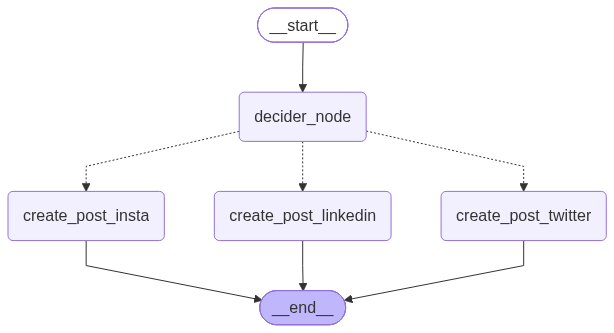

In [115]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("decider_node", decider_node)
graph.add_node("create_post_insta", create_post_insta)
graph.add_node("create_post_twitter", create_post_twitter)
graph.add_node("create_post_linkedin", create_post_linkedin)

graph.add_edge(START, "decider_node")
graph.add_conditional_edges("decider_node", condition,{
    'create_post_insta':'create_post_insta',
    'create_post_twitter':'create_post_twitter',
    'create_post_linkedin':'create_post_linkedin'
})
# graph.add_edge("decider_node","create_post_insta")
# graph.add_edge("decider_node","create_post_twitter")
# graph.add_edge("decider_node","create_post_linkedin")
graph.add_edge("create_post_insta", END)
graph.add_edge("create_post_twitter", END,)
graph.add_edge("create_post_linkedin", END,)




route_graph = graph.compile()

Image(route_graph.get_graph().draw_mermaid_png())

In [116]:
route_graph.invoke(
    {
        "input": "write a twitter post on Artificial Intelligence",
        "topic": "",
        "category":"",
        "post":""
    }
)

category='twitter' topic='Artificial Intelligence'
twitter


{'topic': 'Artificial Intelligence',
 'input': 'write a twitter post on Artificial Intelligence',
 'post': 'The AI revolution isn’t coming—it’s already here. \n\nThe gap between those leveraging these tools and those ignoring them is widening by the hour. Adapt or get left behind. \n\nThe future belongs to the builders. Start now. 🚀🤖 #AI #Tech #Innovation',
 'category': 'twitter'}